[Home](../../README.md)

### Data Preprocessing

This Jupyter Notebook demonstrates different processes you can apply to your data to better understand it before data wrangling. For this demonstration we will use relatively a complex real dataset that compares health measures with the speed of progress of type 2 adult onset diabetes.

#### Load the required dependencies

Load the two required dependencies:

- [Numpy](https://numpy.org/doc/stable/) is a library that enables numerical computing with Python
- [Pandas](https://pandas.pydata.org/) is library for data analysis and manipulation.
- [Matplotlib](https://matplotlib.org) a comprehensive library for creating static, animated, and interactive visualizations in Python. A customised stylesheet for the visualisations is also applied.

In [1]:
# Import frameworks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('../../style_Matplotlib_charts.mplstyle')

####  Store the data as a local variable

The data frame is a Pandas object that structures your tabular data into an appropriate format. It loads the complete data in memory so it is now ready for preprocessing.

In [2]:
data_frame = pd.read_csv("match_data_v5.csv")

#### Data Snapshot

It is important to get a high-level look at your dataset to understand what you are working with. Printing the complete data might be impossible for large-scale datasets where the rows can be in thousands or even millions.

You can use the `head()` and `tail()` method call to inspect the first and last 5 rows of your dataset.

In [3]:
# Target = A measure of disease progression in one year
data_frame.head()

,matchId,blueTeamControlWardsPlaced,blueTeamWardsPlaced,blueTeamTotalKills,blueTeamDragonKills,blueTeamHeraldKills,blueTeamTowersDestroyed,blueTeamInhibitorsDestroyed,blueTeamTurretPlatesDestroyed,blueTeamFirstBlood,...,redTeamHeraldKills,redTeamTowersDestroyed,redTeamInhibitorsDestroyed,redTeamTurretPlatesDestroyed,redTeamMinionsKilled,redTeamJungleMinions,redTeamTotalGold,redTeamXp,redTeamTotalDamageToChamps,blueWin
0,EUW1_6882489515',2,23,4,2,0,0,0,7,0,...,0,2,0,1,400,94,29637,32613,27239,1
1,EUW1_6882416210',2,46,12,1,0,1,0,10,0,...,0,1,0,4,373,76,28970,30320,36585,0
2,EUW1_6881092720',2,19,13,0,0,0,0,11,0,...,0,2,0,3,340,84,30510,29464,42984,0
3,EUW1_6879405717',3,28,8,0,1,1,0,9,1,...,0,0,0,5,378,87,25157,31069,28229,0
4,EUW1_6879389461',3,30,11,1,1,1,0,7,0,...,0,1,0,5,382,96,26052,29475,19245,1


####  Data Summary
 
The `info()` method call prints a summary of each column, giving you more information about the specific data types, total number of rows, null values and memory usage.

In [4]:
data_frame.info()

<class 'pandas.DataFrame'>
RangeIndex: 24225 entries, 0 to 24224
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   matchId                        24225 non-null  str  
 1   blueTeamControlWardsPlaced     24225 non-null  int64
 2   blueTeamWardsPlaced            24225 non-null  int64
 3   blueTeamTotalKills             24225 non-null  int64
 4   blueTeamDragonKills            24225 non-null  int64
 5   blueTeamHeraldKills            24225 non-null  int64
 6   blueTeamTowersDestroyed        24225 non-null  int64
 7   blueTeamInhibitorsDestroyed    24225 non-null  int64
 8   blueTeamTurretPlatesDestroyed  24225 non-null  int64
 9   blueTeamFirstBlood             24225 non-null  int64
 10  blueTeamMinionsKilled          24225 non-null  int64
 11  blueTeamJungleMinions          24225 non-null  int64
 12  blueTeamTotalGold              24225 non-null  int64
 13  blueTeamXp                 

#### Statistics For Numerical Columns
 
The `describe()` method call provides basic statistical knowledge like the mean and spread of the data.

In [5]:
data_frame['redTeamTotalKills'].describe()

count    24225.000000
mean        12.863529
std          4.850884
min          0.000000
25%          9.000000
50%         13.000000
75%         16.000000
max         37.000000
Name: redTeamTotalKills, dtype: float64

#### The data columns are:

| Column | Data |
| ------ | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| matchId | Unique identfier for the match |
| blueTeamControlWardsPlaced | Total control wards placed by the blue team |
| blueTeamWardsPlaced | Total normal wards placed by the blue team |
| blueTeamTotalKills | Total champion kills by the blue team |
| blueTeamDragonKills | Total dragon kills by the blue team |
| blueTeamHeraldKills | Total rift herald kill by the blue team |
| blueTeamTowersDestroyed | Total towers destroyed by the blue team |
| blueTeamInhibitorsDestroyed | Total inhibitors destroyed by the blue team |
| blueTeamTurretPlatesDestroyed | Total turret plates destroyed by the blue team |
| blueTeamFirstBlood | If the blue team got first blood |
| blueTeamMinionsKilled | Total number of minions killed by the blue team |
| blueTeamJungleMinions | total number of jungle camps killed by the blue team |
| blueTeamTotalGold | Total gold gained by the blue team |
| blueTeamXp | Total Xp the blue team has collectively
| blueTeamTotalDamageToChamps | Total damage done to enemy champs by the blue team |
| redTeamControlWardsPlaced | Total control wards placed by the red team |
| redTeamWardsPlaced | Total normal wards placed by the red team |
| redTeamTotalKills | Total champion kills by the red team |
| redTeamDragonKills | Total dragon kills by the red team |
| redTeamHeraldKills | Total Rift Herald kills by the red team |
| redTeamTowersDestroyed | Total towers destroyed by the red team |
| redTeamInhibitorsDestroyed | Total inhibitors destroyed by the red team |
| redTeamTurretPlatesDestroyed | Total turret plates destroyed by the red team |
| redTeamMinionsKilled | Total number of minions killed by the red team |
| redTeamJungleMinions | Total number of jungle camps killed by the red team |
| redTeamTotalGold | Total gold gained by the red team |
| redTeamXp | Total XP the red team has collectively |
| redTeamTotalDamageToChamps | Total damage done to enemy champs by the red team |
| blueWin | If the blue team won the game or not |

#### Graphically present the data

At this early stage you are just wanting to evaluate the data, the below simple plots lets you look the data in different ways to inform your model design and data wrangling approaches.

<Axes: >

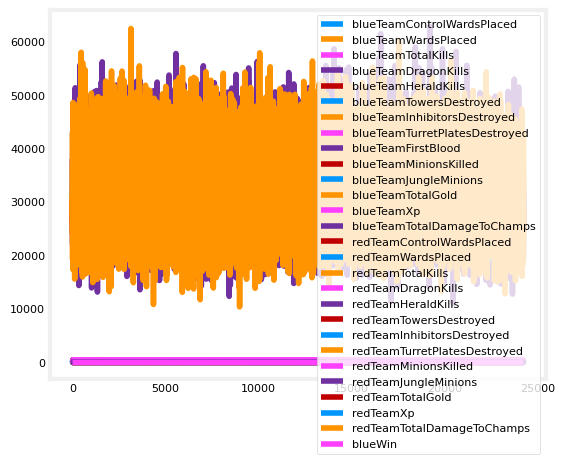

In [6]:
# plot a line graph 
data_frame.plot()

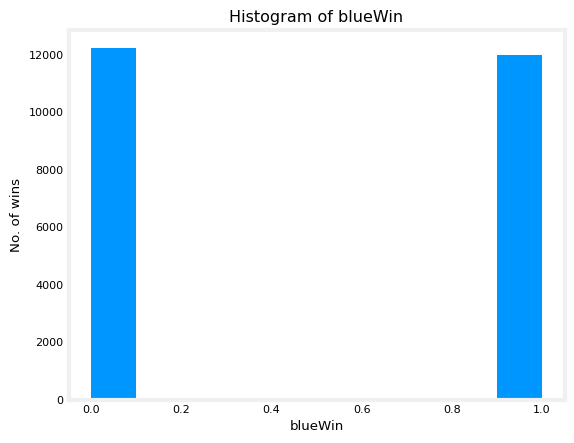

In [7]:
# Plot a histogram of a column
plt.hist(data_frame['blueWin'])
plt.title(f"Histogram of {data_frame['blueWin'].name}")
plt.ylabel('No. of wins')
plt.xlabel(f'{data_frame["blueWin"].name}')
plt.show()

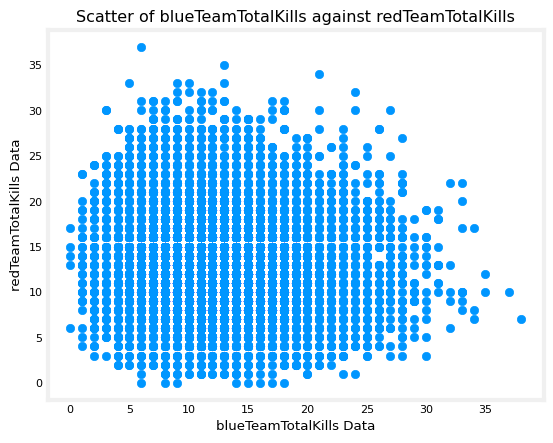

In [8]:
# Scatter plot 2 columns to see the relationship
plt.scatter(data_frame["blueTeamTotalKills"], data_frame["redTeamTotalKills"])
plt.title(
    f"Scatter of {data_frame['blueTeamTotalKills'].name} against {data_frame['redTeamTotalKills'].name}"
)
plt.ylabel(f"{data_frame['redTeamTotalKills'].name} Data")
plt.xlabel(f"{data_frame['blueTeamTotalKills'].name} Data")
plt.show()

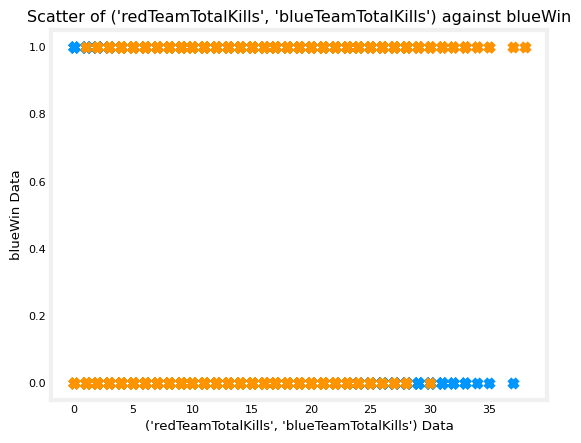

In [9]:
# Scatter plot multiples columns to see the relationship
x_plot = ['redTeamTotalKills', 'blueTeamTotalKills']
for col in x_plot:
    plt.scatter(data_frame[col], data_frame["blueWin"], marker="x")
plt.title(f"Scatter of {*x_plot,} against {data_frame['blueWin'].name}")
plt.ylabel(f"{data_frame['blueWin'].name} Data")
plt.xlabel(f"{*x_plot,} Data")
plt.show()

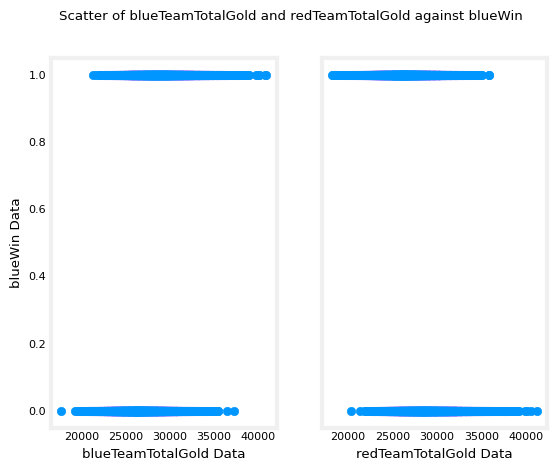

In [10]:
# Scatter plot 2 columns in separate charts with a shared y-axis
fig, (ax1, ax2) = plt.subplots(1,2, sharey=True)
plt.suptitle(f"Scatter of {data_frame['blueTeamTotalGold'].name} and {data_frame['redTeamTotalGold'].name} against {data_frame['blueWin'].name}")
ax1.set_ylabel(f"{data_frame['blueWin'].name} Data")

ax1.scatter(data_frame["blueTeamTotalGold"], data_frame["blueWin"])
ax1.set_xlabel(f"{data_frame['blueTeamTotalGold'].name} Data")

ax2.scatter(data_frame["redTeamTotalGold"], data_frame["blueWin"])
ax2.set_xlabel(f"{data_frame['redTeamTotalGold'].name} Data")

plt.show()

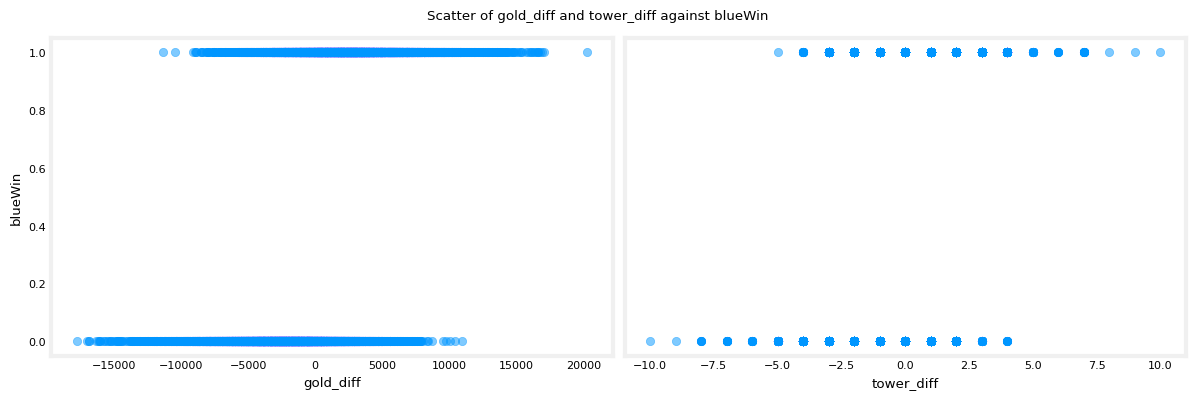

In [11]:
data_frame["gold_diff"] = (
    data_frame["blueTeamTotalGold"] - data_frame["redTeamTotalGold"]
)
data_frame["tower_diff"] = (
    data_frame["blueTeamTowersDestroyed"] - data_frame["redTeamTowersDestroyed"]
)

fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(12, 4))
plt.suptitle("Scatter of gold_diff and tower_diff against blueWin")
ax1.set_ylabel("blueWin")

ax1.scatter(data_frame["gold_diff"], data_frame["blueWin"], alpha=0.5)
ax1.set_xlabel("gold_diff")

ax2.scatter(data_frame["tower_diff"], data_frame["blueWin"], alpha=0.5)
ax2.set_xlabel("tower_diff")

plt.tight_layout()
plt.show()